# Question-answering multiple choice questions

Firts, let's download a public MMLU [dataset](https://huggingface.co/datasets/cais/mmlu) from HuggingFace:

In [1]:
from datasets import load_dataset
ds = load_dataset("cais/mmlu", "high_school_geography")

README.md:   0%|          | 0.00/53.2k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/138k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/28.2k [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/6.16k [00:00<?, ?B/s]

dev-00000-of-00001.parquet:   0%|          | 0.00/3.93k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/198 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/22 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/5 [00:00<?, ? examples/s]

We can explore the dataset:

In [2]:
ds_dict = ds["test"].take(100).to_dict()
print(ds_dict["question"][0])

The main factor preventing subsistence economies from advancing economically is the lack of


In [3]:
print(ds_dict["choices"][0])

['a currency.', 'a well-connected transportation infrastructure.', 'government activity.', 'a banking service.']


In [12]:
ds_dict["choices"][0][ds_dict["answer"][0]]

'a well-connected transportation infrastructure.'

Now, let's create our research agent (pay attention to how we put together the system prompt by describing the agent's profile!):

In [14]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm_small = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=1.0)

/home/ben/anaconda3/envs/langchain_ai/lib/python3.10/site-packages/google/auth/_default.py:76: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [16]:
from langchain_community.agent_toolkits.load_tools import load_tools
from langgraph.prebuilt import create_react_agent


research_tools = load_tools(
  tool_names=["ddg-search", "arxiv", "wikipedia"],
  llm=llm_small
)

system_prompt = (
    "You're a hard-working, curious and creative student. "
    "You're working on exam quesion. Think step by step."
    "Always provide an argumentation for your answer. "
    "Do not assume anything, use available tools to search "
    "for evidence and supporting statements."
)


In [17]:
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langgraph.graph import MessagesState
from langgraph.prebuilt.chat_agent_executor import AgentState

raw_prompt_template = (
    "Answer the following multiple-choice question. "
    "\nQUESTION:\n{question}\n\nANSWER OPTIONS:\n{options}\n"
)
prompt = ChatPromptTemplate.from_messages(
    [("system", system_prompt),
     ("user", raw_prompt_template),
     ("placeholder", "{messages}")
     ]
)

class ResearchState(AgentState):
  question: str
  options: str

research_agent = create_react_agent(model=llm_small, tools=research_tools, state_schema=ResearchState, prompt=prompt)

Now we define another agent that reflects on the anwer and provides critique:

In [18]:
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate


raw_prompt_template_with_critique = (
    "You tried to answer the exam question and you get feedback from your "
    "professor. Work on improving your answer and incorporating the feedback. "
    "\nQUESTION:\n{question}\n\nANSWER OPTIONS:\n{options}\n\n"
    "INITIAL ANSWER:\n{answer}\n\nFEEDBACK:\n{feedback}"

)
prompt = ChatPromptTemplate.from_messages(
    [("system", system_prompt),
     ("user", raw_prompt_template_with_critique),
     ("placeholder", "{messages}")
     ]
)

class ReflectionState(ResearchState):
  answer: str
  feedback: str

research_agent_with_critique = create_react_agent(model=llm_small, tools=research_tools, state_schema=ReflectionState, prompt=prompt)

In [ ]:
from pydantic import BaseModel, Field
from typing import Optional

reflection_prompt = (
    "You are a university professor and you're supervising a student who is "
    "working on a multiple-choice exam question."
    "\nQUESTION: {question}.\nANSWER OPTIONS:\n{options}\n."
    "STUDENT'S ANSWER:\n{answer}\n"
    "Reflect on the student's reasoning and decide whether the answer is right "
    "or wrong. Respond with exactly one of the two fields, never both:\n"
    "- If the answer is correct and sufficiently supported by the reasoning, "
    "fill in 'answer' with the final answer and leave 'critique' empty.\n"
    "- If the answer might be incorrect or the reasoning has flaws, fill in "
    "'critique' with actionable feedback and leave 'answer' empty.\n"
    "Do not assume anything; evaluate only the reasoning the student provided "
    "and whether there is enough evidence for their answer."
)

class Response(BaseModel):
    """A final response to the user."""

    answer: Optional[str] = Field(
        description="The final answer. Provide it only when the student's answer is correct; leave it empty whenever a critique is given.",
        default=None,
    )
    critique: Optional[str] = Field(
        description="Actionable feedback on the initial answer. Provide it only when the answer might be incorrect or the reasoning is flawed; leave it empty whenever a final answer is given.",
        default=None,
    )


Let's put everything together and create a multi-agent system:

In [ ]:
from typing import Annotated, Literal, TypedDict
from langchain_core.runnables.config import RunnableConfig
from operator import add
from langgraph.graph import StateGraph, START, END


class ReflectionAgentState(TypedDict):
    question: str
    options: str
    answer: str
    steps: Annotated[int, add]
    response: Response


def _should_end(state: ReflectionAgentState, config: RunnableConfig) -> Literal["research", END]:
    max_reasoning_steps = config["configurable"].get("max_reasoning_steps", 10)
    # Only stop when we have a final answer and no outstanding critique.
    # If both fields are set, the answer still needs refinement, so keep researching.
    if state.get("response") and state["response"].answer and not state["response"].critique:
        return END
    if state.get("steps", 1) > max_reasoning_steps:
        return END
    return "research"

reflection_chain = PromptTemplate.from_template(reflection_prompt) | llm_small.with_structured_output(Response)

def _reflection_step(state):
    result = reflection_chain.invoke(state)
    return {"response": result, "steps": 1}


def _research_start(state):
  answer = research_agent.invoke(state)
  return {"answer": answer["messages"][-1].content}


def _research(state):
  agent_state = {
      "answer": state["answer"],
      "question": state["question"],
      "options": state["options"],
      "feedback": state["response"].critique
  }
  answer = research_agent_with_critique.invoke(agent_state)
  return {"answer": answer["messages"][-1].content}

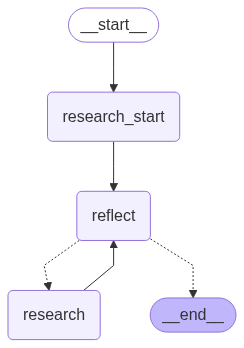

In [23]:
builder = StateGraph(ReflectionAgentState)
builder.add_node("research_start", _research_start)
builder.add_node("research", _research)
builder.add_node("reflect", _reflection_step)

builder.add_edge(START, "research_start")
builder.add_edge("research_start", "reflect")
builder.add_edge("research", "reflect")
builder.add_conditional_edges("reflect", _should_end)
graph = builder.compile()


from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

Let's take a random question and run our agent:

In [24]:
i = 3
question = ds_dict["question"][i]
options = "\n".join([f"{i}. {a}" for i, a in enumerate(ds_dict["choices"][i])])

async for _, event in graph.astream({"question": question, "options": options}, stream_mode=["updates"]):
  print(event)

/home/ben/anaconda3/envs/langchain_ai/lib/python3.10/site-packages/google/auth/_default.py:76: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


{'research_start': {'answer': 'Based on the information from Wikipedia, the zone described in the question is the "Zone of Transition". This zone is characterized by residential deterioration and encroachment by business and light manufacturing, making it the area where low-income slums, ethnic ghettos, and general deterioration are most likely to be found. Therefore, the answer is the second zone.\n\n**Answer:** 1\n'}}
{'reflect': {'response': Response(answer=None, critique='The student\'s answer is based on the "Zone of Transition", which aligns with the characteristics described in the question. However, the question asks for the zone number, and the student correctly identifies it as the second zone. Therefore, the final answer is correct.'), 'steps': 1}}
{'research': {'answer': 'Okay, I understand the feedback. The initial answer was correct, but I need to make sure I\'m clearly stating the zone number in the final answer.\n\nHere\'s the improved answer:\n\nBased on the characteri